In [ ]:
# project description:
# 

In [1]:
# install dependencies
!pip install plotly pandas requests geopy

In [5]:
# download the Epoch AI data
import pandas as pd
import requests
from io import StringIO

dc_url = "https://epoch.ai/data/data_centers/data_centers.csv"
tl_url = "https://epoch.ai/data/data_centers/data_center_timelines.csv"

dc_raw = requests.get(dc_url).text
tl_raw = requests.get(tl_url).text

dc = pd.read_csv(StringIO(dc_raw))
tl = pd.read_csv(StringIO(tl_raw))

print(dc.shape, dc.columns.tolist())
print(tl.shape, tl.columns.tolist())

(43, 15) ['Name', 'Current H100 equivalents', 'Current power (MW)', 'Current total capital cost (2025 USD billions)', 'Owner', 'Users', 'Notes', 'Selected Sources', 'Calculations sheet', 'Project', 'Investors', 'Construction companies', 'Energy companies', 'Country', 'Address']
(247, 14) ['Date', 'Construction status', 'Buildings operational', 'IT power (MW)', 'Power (MW)', 'H100 equivalents', 'Total capital cost (2025 USD billions)', 'Performance (8-bit OP/s)', 'Compute cost (2025 USD billions)', 'Construction cost (2025 USD billions)', 'Water use (MGD)', 'Data center', 'Current H100 equivalents (from Data center)', 'Thumbnail']


In [7]:
# explore data
print(dc[['Name', 'Owner', 'Country', 'Address', 'Current power (MW)']].to_string())

                              Name                  Owner               Country                                                                                                       Address  Current power (MW)
0                       Colossus 2    SpaceXAI #confident         United States                                                                             5420 Tulane Rd, Memphis, TN 38109             1494.00
1      Microsoft Fairwater Atlanta   Microsoft #confident         United States                                                                         1435 Hwy 54 W, Fayetteville, GA 30214              859.00
2    Anthropic-Amazon New Carlisle      Amazon #confident         United States                                                                   55001 Larrison Blvd, New Carlisle, IN 46552             1092.00
3    Microsoft Fairwater Wisconsin   Microsoft #confident         United States                                                                        4800 90th

In [12]:
print(tl[['Date', 'Data center', 'Construction status', 'Power (MW)']].head(30).to_string())

          Date                     Data center                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              Construction status  Power (MW)
0   2018-12-18        Microsoft Project Osmium                                                                                                                                                                                                                                                                              

In [15]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time

# filter to US-only data centers with addresses
us_dc = dc[dc['Country'] == 'United States'].copy()
us_dc = us_dc[us_dc['Address'].notna()].copy()

# clean up 'Owner' column (strip #confident etc)
us_dc['Owner'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner'] = us_dc['Owner'].fillna('Unknown')

# geocode
geolocator = Nominatim(user_agent="datacenter_map")
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

def get_coords(address):
    try:
        loc = geocode(address, timeout=10)
        if loc:
            return loc.latitude, loc.longitude
    except:
        pass
    return None, None

us_dc[['lat', 'lon']] = us_dc['Address'].apply(
    lambda a: pd.Series(get_coords(a))
)

print(us_dc[['Name', 'Owner', 'lat', 'lon']].to_string())

                             Name Owner_clean        lat         lon
0                      Colossus 2    SpaceXAI  34.997983  -90.034867
1     Microsoft Fairwater Atlanta   Microsoft  33.445223  -84.524826
2   Anthropic-Amazon New Carlisle      Amazon        NaN         NaN
3   Microsoft Fairwater Wisconsin   Microsoft  42.674870  -87.894888
4                 Meta Prometheus        Meta        NaN         NaN
5                    QTS Richmond     Unknown  37.488827  -77.247490
6                      Colossus 1    SpaceXAI  35.073554  -90.087308
7         OpenAI Stargate Abilene      Oracle  32.494232  -99.800907
8                 Google Columbus      Google  39.861452  -83.004000
9        Amazon Madison Mega Site      Amazon        NaN         NaN
10              Google New Albany      Google  40.070051  -82.754042
11             Microsoft Goodyear   Microsoft  33.408991 -112.364800
12                    Meta Temple        Meta  31.125960  -97.359818
13                   Google Omaha 

In [22]:
# prep the timeline data ---

# parse dates, join timeline to DC locations
tl['Date'] = pd.to_datetime(tl['Date'])
tl['Year'] = tl['Date'].dt.year

# only keep operational entries (Power > 0)
tl_op = tl[tl['Power (MW)'] > 0].copy()

# for each data center and year, take the max power achieved that year
tl_yearly = (
    tl_op.groupby(['Data center', 'Year'])['Power (MW)']
    .max()
    .reset_index()
)

print(tl_yearly.sort_values(['Data center', 'Year']).to_string())

                       Data center  Year  Power (MW)
0                 Alibaba Zhangbei  2025      102.00
1                 Alibaba Zhangbei  2026      203.00
2         Amazon Madison Mega Site  2025      341.00
3         Amazon Madison Mega Site  2026      819.00
4                 Amazon Ridgeland  2026      273.00
5                 Amazon Ridgeland  2027     1008.00
6    Anthropic-Amazon New Carlisle  2025      751.00
7    Anthropic-Amazon New Carlisle  2026     1229.00
8                       Colossus 1  2024      181.00
9                       Colossus 1  2025      442.00
10                      Colossus 1  2026      425.38
11                      Colossus 2  2025      299.00
12                      Colossus 2  2026     1494.00
13             CoreWeave Denton TX  2025       93.80
14             CoreWeave Denton TX  2026      366.80
15                Coreweave Helios  2026      200.00
16                Coreweave Helios  2028      600.00
17                Coreweave Helios  2029      

In [26]:
# since some cell coordinates are missing, find ai data centers that are missing by filtering

missing = us_dc[us_dc['lat'].isna()][['Name', 'Address']]
print(missing.to_string())



                             Name                                                                                                       Address
2   Anthropic-Amazon New Carlisle                                                                   55001 Larrison Blvd, New Carlisle, IN 46552
4                 Meta Prometheus                                                                         1 Community Cir, New Albany, OH 43054
9        Amazon Madison Mega Site  Amazon Data Services Inc, Madison Mega Site Nissan Parkway and Highway 22 Canton, Mississippi Madison County
16       Microsoft Project Osmium                                                                           5855 SW Kerry St, Cumming, IA 50061
27                      Goodnight                                                                               10001 Lima Rd, Claude, TX 79019
30               Coreweave Helios                                                                          984 County Road 112, Afton, T

Saved.


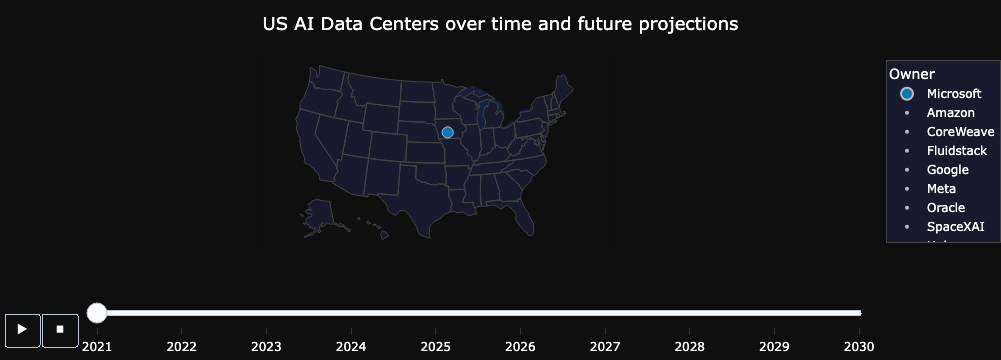

In [106]:
# Fix casing in the source data i.e., Coreweave VS CoreWeave (they are the same thing)

'Owner' == 'Owner_clean'

us_dc['Owner'] = us_dc['Owner'].replace('Coreweave', 'CoreWeave')

us_dc['Owner'] = us_dc['Owner'].str.replace(r'\s*#\w+', '', regex=True).str.strip()
us_dc['Owner'] = us_dc['Owner'].fillna('Unknown')

# build anim_df with fix + dummy points moved to a US location instead of 0,0
all_years = sorted(range(merged['Year'].min(), merged['Year'].max() + 1))
rows = []
for name in merged['Name'].unique():
    site = merged[merged['Name'] == name].set_index('Year')
    owner = us_dc.loc[us_dc['Name'] == name, 'Owner'].iloc[0]
    lat = site['lat'].iloc[0]
    lon = site['lon'].iloc[0]
    for year in all_years:
        past = site[site.index <= year]
        if not past.empty:
            power = past['Power (MW)'].max()
            rows.append({
                'Name': name,
                'Owner': owner,
                'lat': lat,
                'lon': lon,
                'Power (MW)': power,
                'Year': str(year),
            })

anim_df = pd.DataFrame(rows)

# dummy points in Kansas (center of US) so they don't affect zoom
all_owners = anim_df['Owner'].unique()
dummy_rows = []
for year in [str(y) for y in all_years]:
    for owner in all_owners:
        dummy_rows.append({
            'Name': f'__dummy_{owner}',
            'Owner': owner,
            'lat': 38.5, 'lon': -98.0,
            'Power (MW)': 0,
            'Year': year,
        })

anim_df = pd.concat([anim_df, pd.DataFrame(dummy_rows)], ignore_index=True)
anim_df = anim_df.sort_values(['Year', 'Name'])

owner_colors = {
    'Microsoft':  '#00a2ed',
    'Meta': '#1877f2',
    'Google': '#34a853',
    'Amazon':'#ff9900',
    'Oracle':'#f80000',
    'SpaceXAI': '#cc0000',
    'CoreWeave': '#7b2d8b',
    'Fluidstack': '#00b4d8',
    'Unknown': '#aaaaaa',
    'Softbank': '#cc6600',
}

fig = px.scatter_geo(
    anim_df,
    lat='lat', lon='lon',
    size='Power (MW)',
    color='Owner',
    hover_name='Name',
    hover_data={'Power (MW)': True, 'Owner': True, 'lat': False, 'lon': False},
    animation_frame='Year',
    scope='usa',
    size_max=60,
    color_discrete_map=owner_colors,
    title='US AI Data Centers over time and future projections',
)

fig.update_layout(
    geo=dict(
        bgcolor='#0f0f0f',
        landcolor='#1a1a2e',
        lakecolor='#16213e',
        subunitcolor='#444',
        showland=True,
        showlakes=True,
        showsubunits=True,
    ),
    paper_bgcolor='#0f0f0f',
    plot_bgcolor='#0f0f0f',
    font=dict(color='white'),
    legend=dict(bgcolor='#1a1a2e', bordercolor='#444', borderwidth=1),
    title_font=dict(size=18),
    margin=dict(l=0, r=0, t=60, b=0),
)

# Center title
fig.update_layout(title_x=0.5)

# Fix hover labels
fig.update_traces(
    hovertemplate='<b>%{hovertext}</b><br>Owner = %{customdata[0]}<br>Power (MW) = %{customdata[1]}<extra></extra>'
)

fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800
for button in fig.layout.updatemenus[0].buttons:
    button.args[1]['frame']['duration'] = 800

fig.layout.sliders[0].currentvalue.visible = False
fig.write_html('ai_datacenters_animated.html')
print("Saved.")
fig.show()